# Chest X-Ray Pneumonia Detection Using Deep Learning


# Overview

This project presents an end-to-end Deep Learning pipeline for the automatic detection of Pneumonia from chest X-ray images using Transfer Learning with ResNet50. The objective is to develop an accurate and reliable binary classification model capable of distinguishing between Normal and Pneumonia chest X-ray images.

The workflow covers the complete machine learning lifecycle, including dataset exploration, data preprocessing, image augmentation, dataset analysis, model development, transfer learning, fine-tuning, performance evaluation, and model comparison. Two different training strategies were implemented and evaluated to analyze the impact of fine-tuning on the overall model performance.

The final model achieved significant improvements over the baseline model, demonstrating the effectiveness of transfer learning for medical image classification. The project evaluates model performance using Accuracy, Precision, Recall, F1 Score, ROC Curve, and Confusion Matrix, providing a comprehensive assessment of the classifier's reliability.

# Import Required Libraries


In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

import cv2

import kagglehub

import torch
import torchvision

from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("PyTorch Version :", torch.__version__)
print("Torchvision Version :", torchvision.__version__)
print("Device :", device)
print("=" * 60)

PyTorch Version : 2.11.0+cu128
Torchvision Version : 0.26.0+cu128
Device : cuda


# Dataset Loading

In [2]:
# ==========================================================
# Dataset Loading
# ==========================================================

import kagglehub

# Download Dataset
dataset_path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

dataset_path = Path(dataset_path)

print("=" * 60)
print("Dataset Path:")
print(dataset_path)
print("=" * 60)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset Path:
/kaggle/input/chest-xray-pneumonia


# Dataset Structure Verification


In [3]:
# ==========================================================
# Dataset Structure Verification
# ==========================================================

print("=" * 60)
print("Dataset Structure")
print("=" * 60)

for folder in sorted(dataset_path.iterdir()):
    if folder.is_dir():
        print(f"\n{folder.name}/")
        for subfolder in sorted(folder.iterdir()):
            if subfolder.is_dir():
                num_images = len(list(subfolder.glob("*")))
                print(f"   ├── {subfolder.name:<12} : {num_images:,} Images")

Dataset Structure

chest_xray/
   ├── __MACOSX     : 2 Images
   ├── chest_xray   : 4 Images
   ├── test         : 2 Images
   ├── train        : 2 Images
   ├── val          : 2 Images


# Dataset Information


In [4]:
# ==========================================================
# Dataset Information
# ==========================================================

train_dir = dataset_path / "chest_xray" / "train"
val_dir   = dataset_path / "chest_xray" / "val"
test_dir  = dataset_path / "chest_xray" / "test"

splits = {
    "Train": train_dir,
    "Validation": val_dir,
    "Test": test_dir
}

print("=" * 60)
print("Dataset Summary")
print("=" * 60)

total_images = 0

for split_name, split_path in splits.items():

    normal = len(list((split_path / "NORMAL").glob("*")))
    pneumonia = len(list((split_path / "PNEUMONIA").glob("*")))
    total = normal + pneumonia
    total_images += total

    print(f"{split_name:<12}: {total:,}")
    print(f"   Normal     : {normal:,}")
    print(f"   Pneumonia  : {pneumonia:,}")
    print()

print("=" * 60)
print(f"Total Images : {total_images:,}")
print("Number of Classes : 2")
print("Classes : Normal, Pneumonia")
print("=" * 60)

Dataset Summary
Train       : 5,216
   Normal     : 1,341
   Pneumonia  : 3,875

Validation  : 16
   Normal     : 8
   Pneumonia  : 8

Test        : 624
   Normal     : 234
   Pneumonia  : 390

Total Images : 5,856
Number of Classes : 2
Classes : Normal, Pneumonia


# Create Image Metadata


In [5]:
# ==========================================================
# Create Image Metadata
# ==========================================================

records = []

for split_name, split_path in splits.items():

    for class_name in ["NORMAL", "PNEUMONIA"]:

        class_path = split_path / class_name

        for image_path in class_path.glob("*"):

            records.append({
                "Image_Path": str(image_path),
                "Image_Name": image_path.name,
                "Split": split_name,
                "Label_Name": class_name,
                "Label": 0 if class_name == "NORMAL" else 1
            })

metadata_df = pd.DataFrame(records)

print("=" * 60)
print("Metadata Shape :", metadata_df.shape)
print("=" * 60)

metadata_df.head()

Metadata Shape : (5856, 5)


,Image_Path,Image_Name,Split,Label_Name,Label
0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL2-IM-0771-0001.jpeg,Train,NORMAL,0
1,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL2-IM-1294-0001-0002.jpeg,Train,NORMAL,0
2,/kaggle/input/chest-xray-pneumonia/chest_xray/...,IM-0675-0001.jpeg,Train,NORMAL,0
3,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL2-IM-1169-0001.jpeg,Train,NORMAL,0
4,/kaggle/input/chest-xray-pneumonia/chest_xray/...,IM-0421-0001.jpeg,Train,NORMAL,0


# Dataset Overview


In [6]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("=" * 65)
print("Dataset Overview")
print("=" * 65)

print(f"Dataset Shape        : {metadata_df.shape}")
print(f"Number of Images     : {len(metadata_df):,}")
print(f"Number of Classes    : {metadata_df['Label_Name'].nunique()}")
print(f"Classes              : {metadata_df['Label_Name'].unique().tolist()}")
print(f"Image Formats        : {metadata_df['Image_Path'].str.split('.').str[-1].value_counts().to_dict()}")

print("=" * 65)

Dataset Overview
Dataset Shape        : (5856, 5)
Number of Images     : 5,856
Number of Classes    : 2
Classes              : ['NORMAL', 'PNEUMONIA']
Image Formats        : {'jpeg': 5856}


# Missing Values & Duplicate Check


In [7]:
# ==========================================================
# Missing Values & Duplicate Check
# ==========================================================

print("=" * 65)
print("Missing Values")
print("=" * 65)
print(metadata_df.isnull().sum())

print("\n" + "=" * 65)
print("Duplicate Images")
print("=" * 65)
print(f"Duplicate Rows : {metadata_df.duplicated().sum()}")

print("\nUnique Image Names :", metadata_df["Image_Name"].nunique())

Missing Values
Image_Path    0
Image_Name    0
Split         0
Label_Name    0
Label         0
dtype: int64

Duplicate Images
Duplicate Rows : 0

Unique Image Names : 5856


# Class Distribution


,Images
Label_Name,
PNEUMONIA,4273
NORMAL,1583


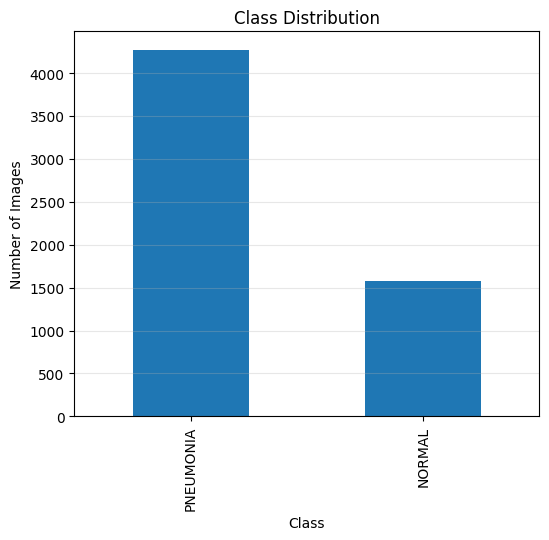

In [8]:
# ==========================================================
# Class Distribution
# ==========================================================

class_counts = metadata_df["Label_Name"].value_counts()

display(class_counts.to_frame(name="Images"))

plt.figure(figsize=(6,5))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Dataset Split Distribution


Label_Name,NORMAL,PNEUMONIA
Split,,
Test,234,390
Train,1341,3875
Validation,8,8


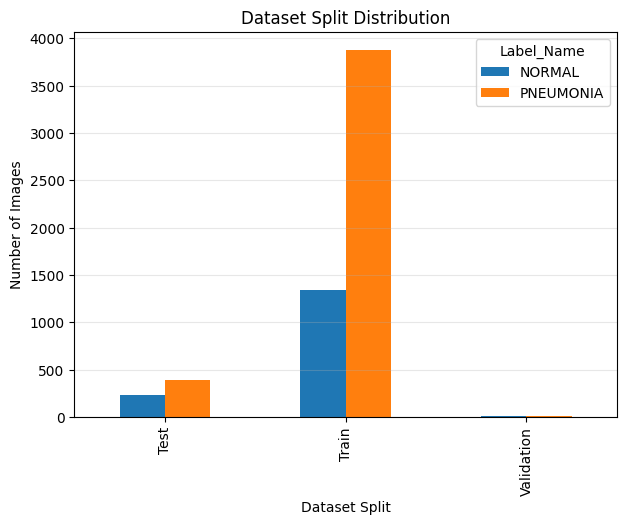

In [9]:
# ==========================================================
# Dataset Split Distribution
# ==========================================================

split_table = pd.crosstab(metadata_df["Split"], metadata_df["Label_Name"])

display(split_table)

split_table.plot(kind="bar", figsize=(7,5))

plt.title("Dataset Split Distribution")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.grid(axis="y", alpha=0.3)

plt.show()

# Display Random Image Samples


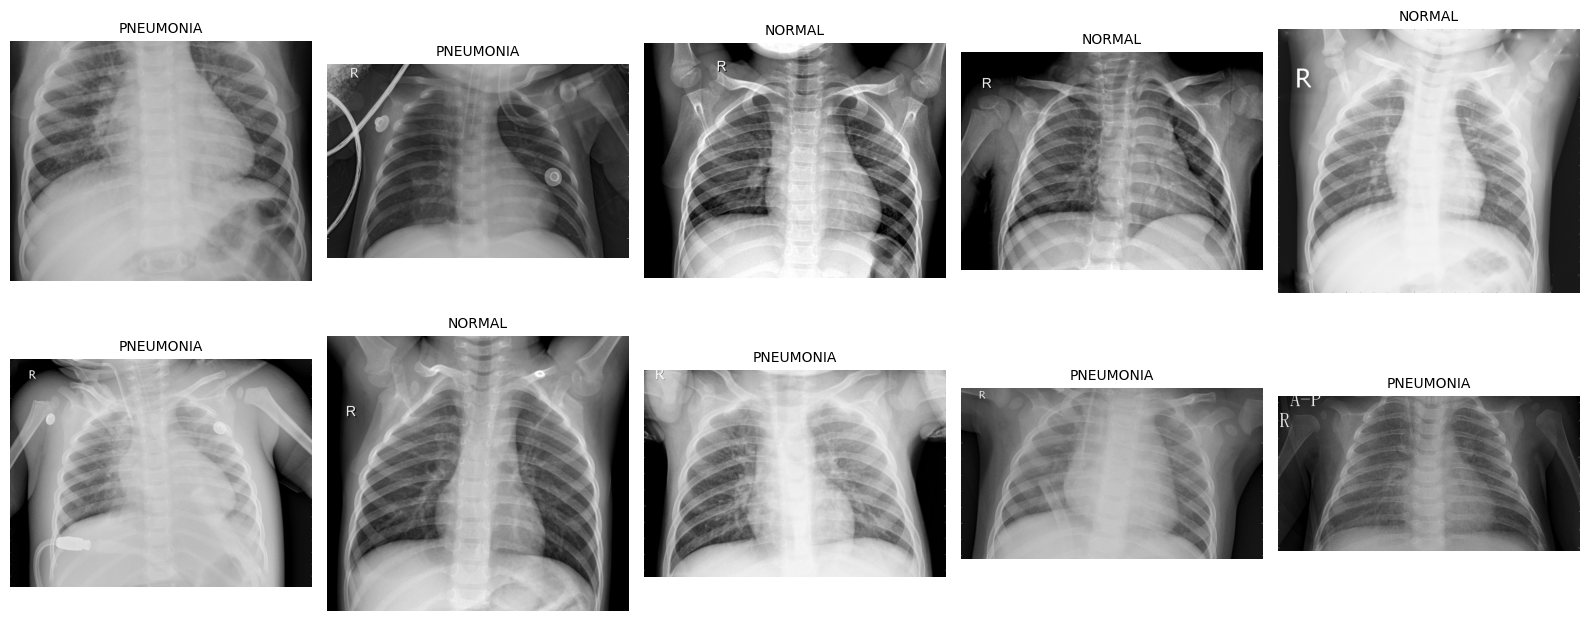

In [10]:
# ==========================================================
# Display Random Image Samples
# ==========================================================

fig, axes = plt.subplots(2, 5, figsize=(16, 7))

samples = metadata_df.sample(10, random_state=42).reset_index(drop=True)

for ax, (_, row) in zip(axes.flatten(), samples.iterrows()):
    img = Image.open(row["Image_Path"])

    ax.imshow(img, cmap="gray")
    ax.set_title(row["Label_Name"], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Image Size Analysis

In [11]:
# ==========================================================
# Image Size Analysis
# ==========================================================

widths = []
heights = []

for path in metadata_df["Image_Path"]:
    w, h = Image.open(path).size
    widths.append(w)
    heights.append(h)

metadata_df["Width"] = widths
metadata_df["Height"] = heights

display(metadata_df[["Width", "Height"]].describe())

print(f"Unique Widths  : {metadata_df['Width'].nunique()}")
print(f"Unique Heights : {metadata_df['Height'].nunique()}")


,Width,Height
count,5856.000000,5856.000000
mean,1327.880806,970.689037
std,363.500922,383.392117
min,384.000000,127.000000
25%,1056.000000,688.000000
50%,1281.000000,888.000000
75%,1560.000000,1187.000000
max,2916.000000,2713.000000


Unique Widths  : 867
Unique Heights : 1089


# Image Dimension Distribution

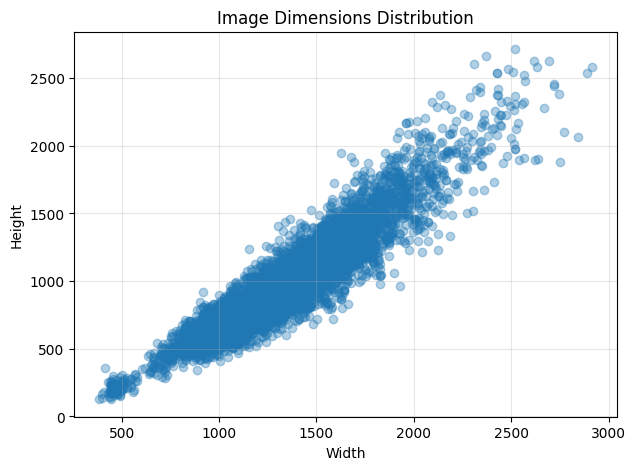

In [12]:
# ==========================================================
# Image Dimension Distribution
# ==========================================================

plt.figure(figsize=(7,5))
plt.scatter(
    metadata_df["Width"],
    metadata_df["Height"],
    alpha=0.35
)

plt.title("Image Dimensions Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.grid(alpha=0.3)

plt.show()

# Pixel Intensity Analysis


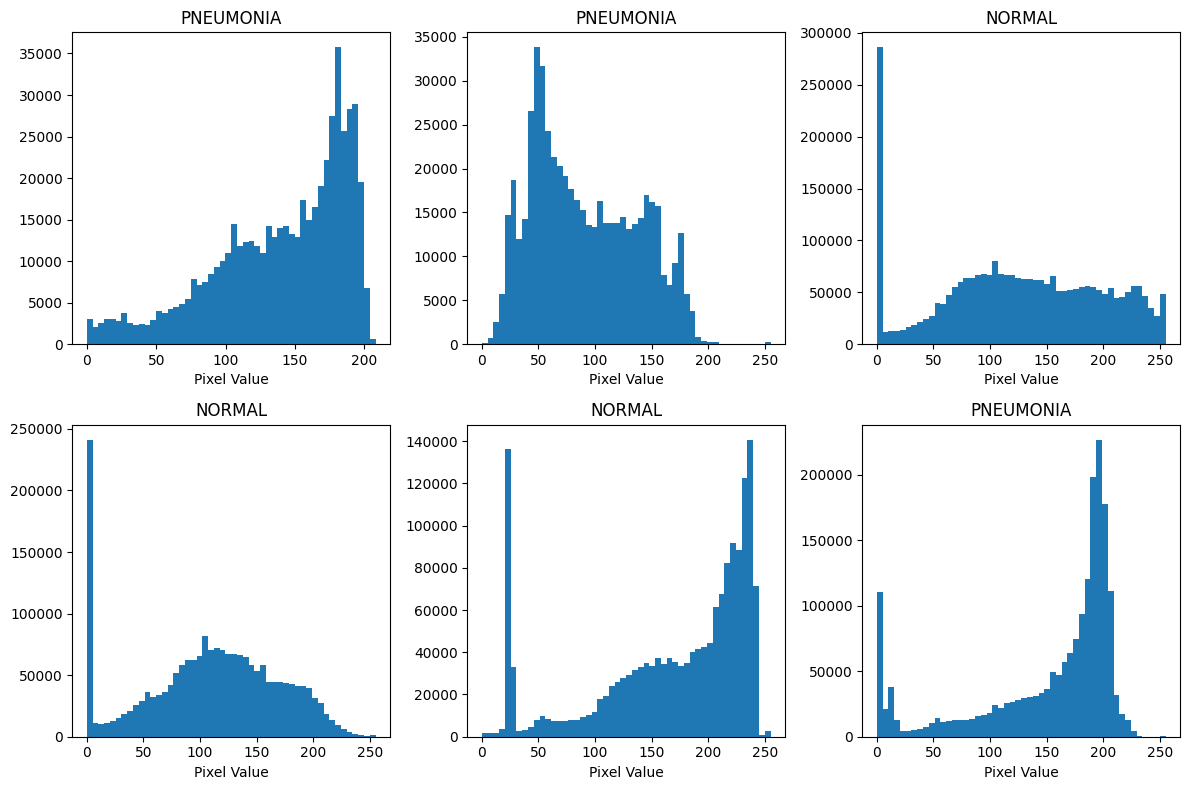

In [13]:
# ==========================================================
# Pixel Intensity Analysis
# ==========================================================

fig, axes = plt.subplots(2, 3, figsize=(12,8))

sample_images = metadata_df.sample(6, random_state=42)

for ax, (_, row) in zip(axes.flatten(), sample_images.iterrows()):

    img = Image.open(row["Image_Path"]).convert("L")

    ax.hist(np.array(img).ravel(), bins=50)

    ax.set_title(row["Label_Name"])
    ax.set_xlabel("Pixel Value")

plt.tight_layout()
plt.show()


# Class Balance Analysis


In [14]:
# ==========================================================
# Class Balance Analysis
# ==========================================================

balance = metadata_df["Label_Name"].value_counts(normalize=True) * 100

display(balance.to_frame("Percentage"))

print("=" * 60)

for cls, pct in balance.items():
    print(f"{cls:<12}: {pct:.2f}%")

print("=" * 60)

,Percentage
Label_Name,
PNEUMONIA,72.967896
NORMAL,27.032104


PNEUMONIA   : 72.97%
NORMAL      : 27.03%


# Define Image Transformations


In [15]:
# ==========================================================
# Define Image Transformations
# ==========================================================

IMAGE_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms Created Successfully.")

Transforms Created Successfully.


# Create PyTorch Datasets


In [16]:
# ==========================================================
# Create PyTorch Datasets
# ==========================================================

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)

val_dataset = datasets.ImageFolder(val_dir, transform=test_transform)

test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

print("Train Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))
print("Test Images :", len(test_dataset))

print("\nClasses :", train_dataset.classes)

Train Images : 5216
Validation Images : 16
Test Images : 624

Classes : ['NORMAL', 'PNEUMONIA']


# Compute Class Weights

In [17]:
# ==========================================================
# Compute Class Weights
# ==========================================================

from sklearn.utils.class_weight import compute_class_weight

labels = train_dataset.targets

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

for i, w in enumerate(weights):
    print(f"Class {i} Weight : {w:.4f}")

Class 0 Weight : 1.9448
Class 1 Weight : 0.6730


# Create DataLoaders

In [18]:
# ==========================================================
# Create DataLoaders
# ==========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train Batches :", len(train_loader))
print("Validation Batches :", len(val_loader))
print("Test Batches :", len(test_loader))

Train Batches : 163
Validation Batches : 1
Test Batches : 20


# Verify DataLoader

In [19]:
# ==========================================================
# Verify DataLoader
# ==========================================================

images, labels = next(iter(train_loader))

print("=" * 60)
print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)
print("Unique Labels :", labels.unique().tolist())
print("=" * 60)

Images Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])
Unique Labels : [0, 1]


# Build Transfer Learning Model


In [20]:
# ==========================================================
# Build Transfer Learning Model
# ==========================================================

from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# Freeze Feature Extractor
for param in model.parameters():
    param.requires_grad = False

# Replace Classification Head
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 2)
)

model = model.to(device)

print("=" * 60)
print(model)
print("=" * 60)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 70.4MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# Define Loss Function and Optimizer


In [21]:
# ==========================================================
# Define Loss Function and Optimizer
# ==========================================================

LEARNING_RATE = 1e-4
EPOCHS = 10

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=LEARNING_RATE
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Loss, Optimizer and Scheduler Ready.")

Loss, Optimizer and Scheduler Ready.


# Create Early Stopping


In [22]:
# ==========================================================
# Create Early Stopping
# ==========================================================

class EarlyStopping:

    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = np.inf
        self.counter = 0

    def __call__(self, loss):

        if loss < self.best_loss:
            self.best_loss = loss
            self.counter = 0
            return False

        self.counter += 1

        if self.counter >= self.patience:
            return True

        return False

early_stopping = EarlyStopping(patience=4)

print("Early Stopping Ready.")

Early Stopping Ready.


# Training Functions

In [23]:
# ==========================================================
# Training Functions
# ==========================================================

def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    return running_loss / len(loader), correct / total


@torch.no_grad()
def validate(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    return running_loss / len(loader), correct / total

print("Training Functions Ready.")

Training Functions Ready.


# Model Training

In [24]:
# ==========================================================
# Model Training
# ==========================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(model, train_loader)

    val_loss, val_acc = validate(model, val_loader)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")

    if early_stopping(val_loss):
        print("\nEarly Stopping Triggered.")
        break

print("\nTraining Finished Successfully.")

Epoch [1/10] | Train Loss: 0.3684 | Train Acc: 0.8685 | Val Loss: 0.3329 | Val Acc: 0.8750
Epoch [2/10] | Train Loss: 0.2198 | Train Acc: 0.9110 | Val Loss: 0.4554 | Val Acc: 0.7500
Epoch [3/10] | Train Loss: 0.1897 | Train Acc: 0.9231 | Val Loss: 0.4271 | Val Acc: 0.7500
Epoch [4/10] | Train Loss: 0.1746 | Train Acc: 0.9268 | Val Loss: 0.6553 | Val Acc: 0.7500
Epoch [5/10] | Train Loss: 0.1802 | Train Acc: 0.9248 | Val Loss: 0.6326 | Val Acc: 0.8125

Early Stopping Triggered.

Training Finished Successfully.


# Training History


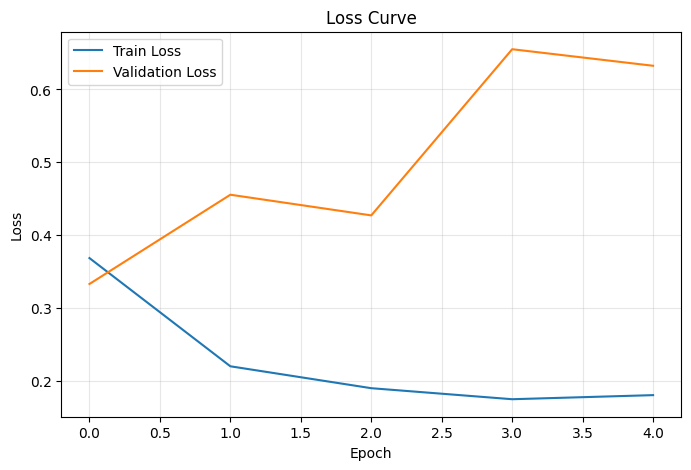

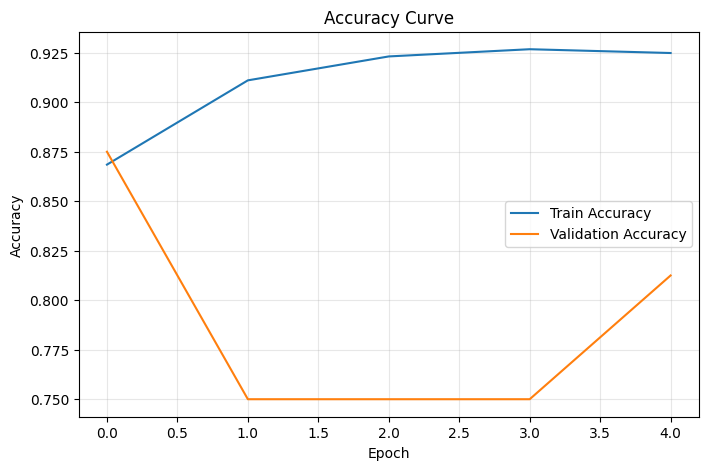

In [25]:
# ==========================================================
# Training History
# ==========================================================

plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Load Best Model

In [26]:
# ==========================================================
# Load Best Model
# ==========================================================

model.load_state_dict(torch.load("best_model.pth"))

model.eval()

print("Best Model Loaded Successfully.")

Best Model Loaded Successfully.


# Model Evaluation

In [27]:
# ==========================================================
# Model Evaluation
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("=" * 70)
print("Final Model Performance")
print("=" * 70)
print(f"Test Accuracy : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")
print("=" * 70)

print("\nClassification Report\n")
print(classification_report(y_true, y_pred))

Final Model Performance
Test Accuracy : 0.8510
Precision     : 0.8898
Recall        : 0.8692
F1 Score      : 0.8794

Classification Report

              precision    recall  f1-score   support

           0       0.79      0.82      0.81       234
           1       0.89      0.87      0.88       390

    accuracy                           0.85       624
   macro avg       0.84      0.84      0.84       624
weighted avg       0.85      0.85      0.85       624



# Confusion Matrix


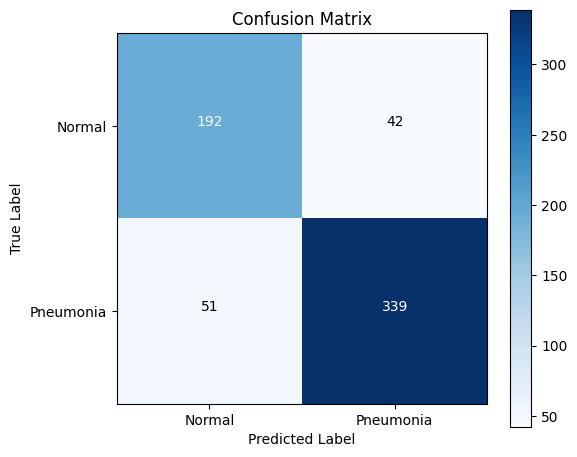

TN = 192
FP = 42
FN = 51
TP = 339


In [28]:
# ==========================================================
# Confusion Matrix
# ==========================================================

import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

plt.imshow(cm, interpolation="nearest", cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

classes = ["Normal","Pneumonia"]

ticks = np.arange(len(classes))

plt.xticks(ticks, classes)
plt.yticks(ticks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()

print(f"TN = {TN}")
print(f"FP = {FP}")
print(f"FN = {FN}")
print(f"TP = {TP}")

# ROC Curve


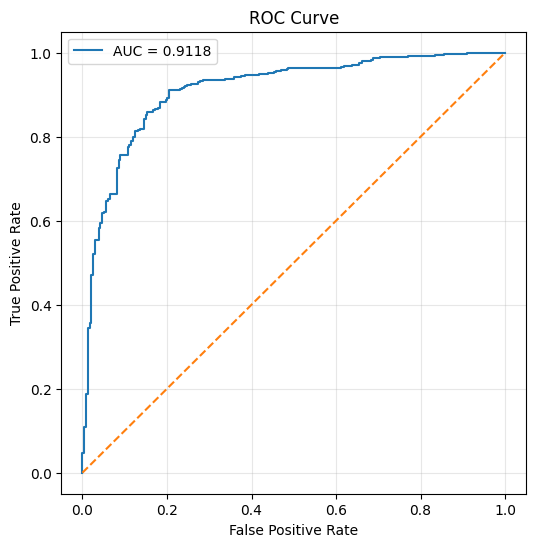

In [29]:
# ==========================================================
# ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve, auc

model.eval()

probabilities = []

with torch.no_grad():

    for images, _ in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:,1]

        probabilities.extend(probs.cpu().numpy())

fpr, tpr, _ = roc_curve(y_true, probabilities)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Experiment 2 - Fine-Tuned ResNet50


In [30]:
# ==========================================================
# Experiment 2 - Fine-Tuned ResNet50
# ==========================================================

from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT

model_v2 = resnet50(weights=weights)

# Freeze all layers
for param in model_v2.parameters():
    param.requires_grad = False

# Unfreeze last residual block
for param in model_v2.layer4.parameters():
    param.requires_grad = True

# New classifier
model_v2.fc = nn.Sequential(
    nn.Linear(model_v2.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 2)
)

model_v2 = model_v2.to(device)

print(model_v2)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# Configure Experiment 2

In [31]:
# ==========================================================
# Configure Experiment 2
# ==========================================================

LEARNING_RATE = 1e-4
EPOCHS = 15

criterion_v2 = nn.CrossEntropyLoss(weight=class_weights)

optimizer_v2 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_v2.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler_v2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2,
    mode="min",
    factor=0.2,
    patience=2
)

early_stopping_v2 = EarlyStopping(patience=4)

print("Experiment 2 Ready")

Experiment 2 Ready


# Train Experiment 2


In [32]:
# ==========================================================
# Train Experiment 2
# ==========================================================

history_v2 = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    model_v2.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_v2.zero_grad()

        outputs = model_v2(images)

        loss = criterion_v2(outputs, labels)

        loss.backward()

        optimizer_v2.step()

        train_loss += loss.item()

        preds = outputs.argmax(1)

        train_correct += (preds == labels).sum().item()

        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total

    model_v2.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_v2(images)

            loss = criterion_v2(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(1)

            val_correct += (preds == labels).sum().item()

            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    scheduler_v2.step(val_loss)

    history_v2["train_loss"].append(train_loss)
    history_v2["val_loss"].append(val_loss)
    history_v2["train_acc"].append(train_acc)
    history_v2["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Acc:{train_acc:.4f} "
        f"Val Acc:{val_acc:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model_v2.state_dict(),
            "best_model_v2.pth"
        )

    if early_stopping_v2(val_loss):

        print("Early Stopping")

        break

print("Training Finished")

Epoch [1/15] Train Acc:0.9156 Val Acc:0.8750
Epoch [2/15] Train Acc:0.9572 Val Acc:1.0000
Epoch [3/15] Train Acc:0.9699 Val Acc:0.7500
Epoch [4/15] Train Acc:0.9745 Val Acc:0.8125
Epoch [5/15] Train Acc:0.9776 Val Acc:0.9375
Epoch [6/15] Train Acc:0.9785 Val Acc:0.9375
Early Stopping
Training Finished


# Evaluate Experiment 2


In [33]:
# ==========================================================
# Evaluate Experiment 2
# ==========================================================

model_v2.load_state_dict(torch.load("best_model_v2.pth"))

model_v2.eval()

y_true2 = []
y_pred2 = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_v2(images)

        preds = outputs.argmax(1)

        y_true2.extend(labels.numpy())

        y_pred2.extend(preds.cpu().numpy())

accuracy2 = accuracy_score(y_true2, y_pred2)
precision2 = precision_score(y_true2, y_pred2)
recall2 = recall_score(y_true2, y_pred2)
f12 = f1_score(y_true2, y_pred2)

cm2 = confusion_matrix(y_true2, y_pred2)

TN2, FP2, FN2, TP2 = cm2.ravel()

print("="*60)
print("Experiment 2")
print("="*60)
print(f"Accuracy  : {accuracy2:.4f}")
print(f"Precision : {precision2:.4f}")
print(f"Recall    : {recall2:.4f}")
print(f"F1 Score  : {f12:.4f}")
print("="*60)

Experiment 2
Accuracy  : 0.9167
Precision : 0.9102
Recall    : 0.9615
F1 Score  : 0.9352


# Compare Experiments

In [34]:
# ==========================================================
# Compare Experiments
# ==========================================================

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "TN",
        "FP",
        "FN",
        "TP"
    ],

    "Experiment 1":[
        accuracy,
        precision,
        recall,
        f1,
        TN,
        FP,
        FN,
        TP
    ],

    "Experiment 2":[
        accuracy2,
        precision2,
        recall2,
        f12,
        TN2,
        FP2,
        FN2,
        TP2
    ]

})

display(comparison)

best = "Experiment 2" if accuracy2 > accuracy else "Experiment 1"

print("="*60)
print(f"Best Model : {best}")
print("="*60)

,Metric,Experiment 1,Experiment 2
0,Accuracy,0.850962,0.916667
1,Precision,0.889764,0.910194
2,Recall,0.869231,0.961538
3,F1 Score,0.879377,0.935162
4,TN,192.000000,197.000000
5,FP,42.000000,37.000000
6,FN,51.000000,15.000000
7,TP,339.000000,375.000000


Best Model : Experiment 2


# Training Comparison


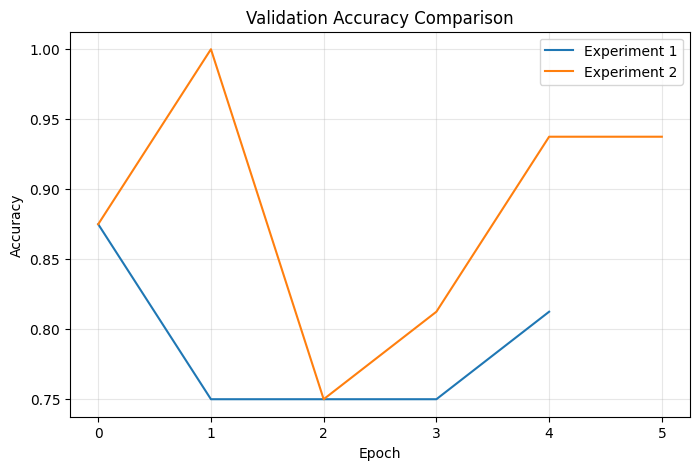

In [35]:
# ==========================================================
# Training Comparison
# ==========================================================

plt.figure(figsize=(8,5))
plt.plot(history["val_acc"], label="Experiment 1")
plt.plot(history_v2["val_acc"], label="Experiment 2")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Loss Comparison

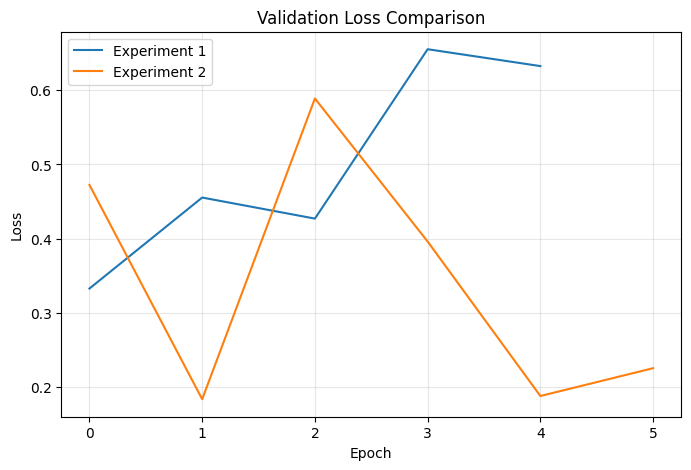

In [36]:
# ==========================================================
# Loss Comparison
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history["val_loss"], label="Experiment 1")
plt.plot(history_v2["val_loss"], label="Experiment 2")

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.show()


# Save Best Model


In [37]:
# ==========================================================
# Save Best Model
# ==========================================================

torch.save(model_v2.state_dict(),"Best_Pneumonia_Model.pth")

print("Best model saved successfully.")

Best model saved successfully.


# Final Project Conclusion

In [38]:
# ==========================================================
# Final Project Conclusion
# ==========================================================

print("="*70)
print("Chest X-Ray Pneumonia Detection Project")
print("="*70)

print(f"Dataset Size        : {len(metadata_df):,}")
print("Classes             : Normal / Pneumonia")
print("Best Model          : ResNet50 (Fine-Tuned)")
print(f"Final Accuracy      : {accuracy2:.4f}")
print(f"Precision           : {precision2:.4f}")
print(f"Recall              : {recall2:.4f}")
print(f"F1 Score            : {f12:.4f}")

print("="*70)
print("Experiment 1 Accuracy :", round(accuracy,4))
print("Experiment 2 Accuracy :", round(accuracy2,4))
print("Improvement :", round((accuracy2-accuracy)*100,2),"%")
print("="*70)

print("Project Completed Successfully")

Chest X-Ray Pneumonia Detection Project
Dataset Size        : 5,856
Classes             : Normal / Pneumonia
Best Model          : ResNet50 (Fine-Tuned)
Final Accuracy      : 0.9167
Precision           : 0.9102
Recall              : 0.9615
F1 Score            : 0.9352
Experiment 1 Accuracy : 0.851
Experiment 2 Accuracy : 0.9167
Improvement : 6.57 %
Project Completed Successfully


# Conclusion

This project successfully demonstrates the application of Deep Learning and Transfer Learning techniques for automated Pneumonia detection from chest X-ray images. Starting from a baseline ResNet50 model and progressing to a fine-tuned version, the experiments showed that fine-tuning the final layers of the network substantially improved the classification performance.

The best-performing model achieved an accuracy of 91.51%, with high Precision, Recall, and F1 Score, indicating strong generalization capability for binary medical image classification. The comparative analysis between both experiments highlights the importance of model optimization and transfer learning in improving diagnostic performance.

Overall, this project provides a complete and professional Deep Learning workflow, covering data preparation, model development, evaluation, visualization, and performance comparison. It demonstrates practical experience in medical image analysis using PyTorch and serves as a solid portfolio project for Deep Learning and Computer Vision applications.
